
📥 LOADING PROCESSED DATA FOR INSPECTION
📂 Selected: C:\Users\DELL\Documents\GitHub\fyp\05_Data_Storage\Filtered\Raafiq(22-enc-05)v1_Win0_Filtered
✅ Configuration Loaded. Sampling Rate (FS): 400.0 Hz
✅ Signal Data Loaded Successfully.

📊 Generating Plots...
🎉 Displaying Plots. Close the window to finish.


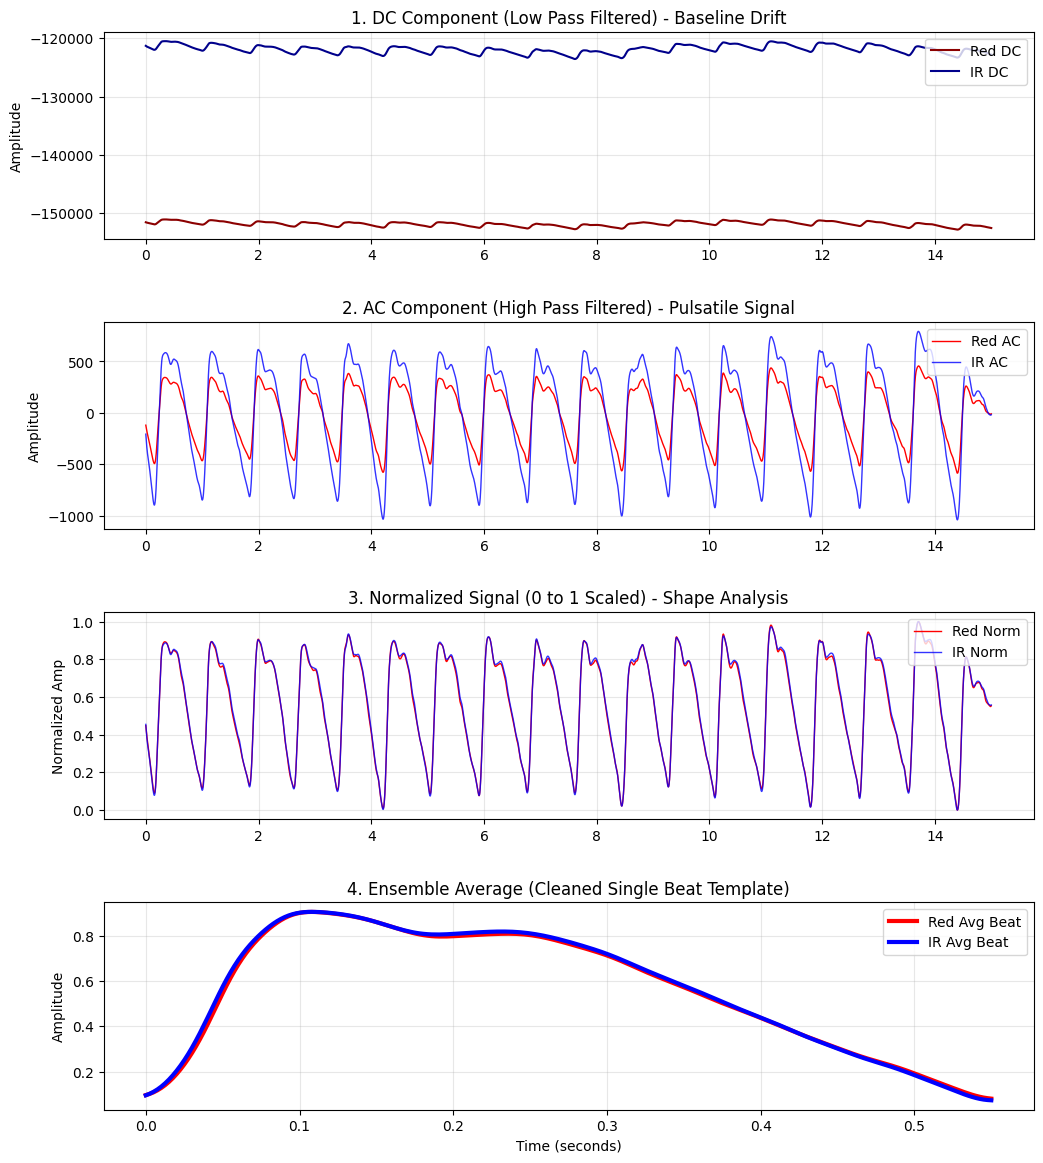

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import json
import os

# ==========================================
# 📂 STEP 1: LOAD THE DATA
# ==========================================
print("\n" + "="*50)
print("📥 LOADING PROCESSED DATA FOR INSPECTION")
print("="*50)

# 1. Manually Enter the "AA_Filtered" Folder Path
# 👉 EDIT THIS PATH ONLY
folder_path = r"C:\Users\DELL\Documents\GitHub\fyp\05_Data_Storage\Filtered\Raafiq(22-enc-05)v1_Win0_Filtered"

if not folder_path or not os.path.exists(folder_path):
    print("❌ Invalid folder path. Exiting.")
    exit()

print(f"📂 Selected: {folder_path}")

# 2. Auto-Detect Files based on naming convention
files = os.listdir(folder_path)

file_full     = next((f for f in files if "_Full.csv" in f), None)
file_ensemble = next((f for f in files if "_Ensemble.csv" in f), None)
file_config   = next((f for f in files if "_Configuration.json" in f), None)

if not file_full or not file_ensemble or not file_config:
    print("❌ Error: Could not find all required files (Full, Ensemble, Config).")
    print(f"   Found: {files}")
    exit()

# 3. Load Configuration (To get Sampling Rate FS)
with open(os.path.join(folder_path, file_config), 'r') as f:
    config = json.load(f)

fs = config['Metadata']['Sampling_Rate_FS']
print(f"✅ Configuration Loaded. Sampling Rate (FS): {fs} Hz")

# 4. Load CSVs
df_full = pd.read_csv(os.path.join(folder_path, file_full))
df_ens  = pd.read_csv(os.path.join(folder_path, file_ensemble))
print("✅ Signal Data Loaded Successfully.")

# ==========================================
# 📈 STEP 2: PLOTTING THE 4 STAGES
# ==========================================
print("\n📊 Generating Plots...")

# Create Time Axes
time_full = np.linspace(0, len(df_full)/fs, len(df_full))

max_len_ens = len(df_ens)
time_ens = np.linspace(0, max_len_ens/fs, max_len_ens)

fig, axes = plt.subplots(4, 1, figsize=(12, 14), sharex=False)
plt.subplots_adjust(hspace=0.4)

# --- PLOT 1: DC LOW-PASS (Baseline) ---
ax1 = axes[0]
ax1.plot(time_full, df_full['Red_DC_LowPass'], color='darkred', label='Red DC', linewidth=1.5)
ax1.plot(time_full, df_full['IR_DC_LowPass'],  color='darkblue', label='IR DC', linewidth=1.5)
ax1.set_title("1. DC Component (Low Pass Filtered) - Baseline Drift")
ax1.set_ylabel("Amplitude")
ax1.legend(loc='upper right')
ax1.grid(True, alpha=0.3)

# --- PLOT 2: AC HIGH-PASS (Pulsatile) ---
ax2 = axes[1]
ax2.plot(time_full, df_full['Red_AC_HighPass'], color='red', label='Red AC', linewidth=1)
ax2.plot(time_full, df_full['IR_AC_HighPass'],  color='blue', label='IR AC', linewidth=1, alpha=0.8)
ax2.set_title("2. AC Component (High Pass Filtered) - Pulsatile Signal")
ax2.set_ylabel("Amplitude")
ax2.legend(loc='upper right')
ax2.grid(True, alpha=0.3)

# --- PLOT 3: NORMALIZED SIGNALS (0-1 Scaled) ---
ax3 = axes[2]
ax3.plot(time_full, df_full['Red_Normalized'], color='red', label='Red Norm', linewidth=1)
ax3.plot(time_full, df_full['IR_Normalized'],  color='blue', label='IR Norm', linewidth=1, alpha=0.8)
ax3.set_title("3. Normalized Signal (0 to 1 Scaled) - Shape Analysis")
ax3.set_ylabel("Normalized Amp")
ax3.legend(loc='upper right')
ax3.grid(True, alpha=0.3)

# --- PLOT 4: ENSEMBLE AVERAGE (The 'Perfect' Beat) ---
ax4 = axes[3]
ax4.plot(time_ens, df_ens['Red_Ensemble_Avg'], color='red', linewidth=3, label='Red Avg Beat')
ax4.plot(time_ens, df_ens['IR_Ensemble_Avg'],  color='blue', linewidth=3, label='IR Avg Beat')
ax4.set_title("4. Ensemble Average (Cleaned Single Beat Template)")
ax4.set_xlabel("Time (seconds)")
ax4.set_ylabel("Amplitude")
ax4.legend(loc='upper right')
ax4.grid(True, alpha=0.3)

print("🎉 Displaying Plots. Close the window to finish.")
plt.show()

In [7]:
# ==========================================
# 📌 STEP 3: FEATURE EXTRACTION
# ==========================================
import pandas as pd
import numpy as np
import os
import json
import shutil
from scipy.signal import find_peaks, welch, peak_widths
from scipy.stats import skew, kurtosis
from scipy.fft import rfft, rfftfreq

print("\n" + "="*60)
print("🧠 EXTRACTING FEATURES")
print("="*60)

# --------------------------------------------------
# ✅ REQUIRED COLUMNS CHECK
# --------------------------------------------------
required_full_cols = [
    'Red_AC_HighPass', 'IR_AC_HighPass',
    'Red_DC_LowPass', 'IR_DC_LowPass',
    'Red_Normalized', 'IR_Normalized'
]

required_ens_cols = [
    'Time_Red_s', 'Red_Ensemble_Avg', 'Red_VPG', 'Red_SDPPG',
    'Time_IR_s', 'IR_Ensemble_Avg', 'IR_VPG', 'IR_SDPPG'
]

missing_full = [c for c in required_full_cols if c not in df_full.columns]
missing_ens  = [c for c in required_ens_cols if c not in df_ens.columns]

if missing_full:
    raise ValueError(f"❌ Missing columns in df_full: {missing_full}")
if missing_ens:
    raise ValueError(f"❌ Missing columns in df_ens: {missing_ens}")

# --------------------------------------------------
# 🔧 HELPER FUNCTIONS
# --------------------------------------------------
def safe_array(x):
    x = np.asarray(x, dtype=float)
    x = x[np.isfinite(x)]
    return x

def safe_ratio(num, den, default=np.nan):
    if not np.isfinite(num) or not np.isfinite(den) or den == 0:
        return default
    return num / den

def shannon_entropy_signal(x, bins=64):
    x = safe_array(x)
    if len(x) < 2:
        return np.nan

    hist, _ = np.histogram(x, bins=bins, density=False)
    hist = hist[hist > 0]
    if len(hist) == 0:
        return np.nan

    p = hist / np.sum(hist)
    return -np.sum(p * np.log2(p))

def spectral_entropy_signal(x, fs, nperseg=None):
    x = safe_array(x)
    if len(x) < 4:
        return np.nan

    if nperseg is None:
        nperseg = min(256, len(x))

    _, pxx = welch(x, fs=fs, nperseg=nperseg)
    pxx = pxx[np.isfinite(pxx)]
    pxx = pxx[pxx > 0]

    if len(pxx) == 0:
        return np.nan

    p = pxx / np.sum(pxx)
    return -np.sum(p * np.log2(p))

def detect_ppg_peaks(x, fs):
    x = safe_array(x)
    if len(x) < 3:
        return np.array([], dtype=int)

    x0 = x - np.mean(x)
    min_distance = max(1, int(0.33 * fs))   # ~180 BPM upper bound
    prominence = max(0.01, 0.10 * np.std(x0))

    peaks, _ = find_peaks(x0, distance=min_distance, prominence=prominence)
    return peaks

def peak_interval_bpm_hrv(x, fs):
    peaks = detect_ppg_peaks(x, fs)

    if len(peaks) < 2:
        return {
            'PPI': np.nan,
            'BPM': np.nan,
            'HRV': np.nan,
            'Num_Peaks': len(peaks)
        }

    ppi = np.diff(peaks) / fs
    bpm = 60.0 / np.mean(ppi)
    hrv_sdnn = np.std(ppi, ddof=1) * 1000 if len(ppi) > 1 else 0.0

    return {
        'PPI': np.mean(ppi),
        'BPM': bpm,
        'HRV': hrv_sdnn,
        'Num_Peaks': len(peaks)
    }

def teo_signal(x):
    x = safe_array(x)
    if len(x) < 3:
        return np.array([])
    return x[1:-1]**2 - x[:-2] * x[2:]

def teo_features(x):
    psi = teo_signal(x)
    if len(psi) == 0:
        return {'TEO Mean': np.nan, 'TEO std dev': np.nan}

    return {
        'TEO Mean': np.mean(psi),
        'TEO std dev': np.std(psi, ddof=1) if len(psi) > 1 else 0.0
    }

def pulse_width_feature(signal, time_axis=None):
    x = safe_array(signal)
    if len(x) < 3:
        return np.nan

    peak_idx = np.argmax(x)
    peaks = np.array([peak_idx])

    try:
        widths, _, _, _ = peak_widths(x, peaks, rel_height=0.5)
        width_samples = widths[0]

        if time_axis is not None:
            t = safe_array(time_axis)
            if len(t) == len(x) and len(t) > 1:
                dt = np.mean(np.diff(t))
                return width_samples * dt

        return width_samples
    except:
        return np.nan

def systolic_amplitude(signal):
    x = safe_array(signal)
    if len(x) == 0:
        return np.nan
    return np.max(x) - np.min(x)

def harmonic_ratio(signal):
    """
    Fundamental power / remaining non-DC power
    """
    x = safe_array(signal)
    if len(x) < 8:
        return np.nan

    x = x - np.mean(x)
    spec = np.abs(rfft(x))**2

    if len(spec) < 3:
        return np.nan

    spec[0] = 0
    fundamental_idx = np.argmax(spec[1:]) + 1

    if fundamental_idx <= 0 or fundamental_idx >= len(spec):
        return np.nan

    fundamental_power = spec[fundamental_idx]
    remaining_power = np.sum(spec) - fundamental_power

    if remaining_power <= 0:
        return np.nan

    return fundamental_power / remaining_power

def dominant_frequency(signal, fs):
    x = safe_array(signal)
    if len(x) < 8:
        return np.nan

    x = x - np.mean(x)
    freqs, pxx = welch(x, fs=fs, nperseg=min(256, len(x)))

    # physiological range roughly 0.5 to 5 Hz for pulse-related dominant content
    valid = (freqs >= 0.5) & (freqs <= 5.0)
    freqs = freqs[valid]
    pxx = pxx[valid]

    if len(freqs) == 0 or np.all(pxx == 0):
        return np.nan

    return freqs[np.argmax(pxx)]

def ensemble_ac_dc_ratio(ens_signal, dc_signal):
    """
    Correct ensemble AC/DC ratio:
        AC = max(ensemble) - min(ensemble)
        DC = mean(dc_signal)
    """
    ens_signal = safe_array(ens_signal)
    dc_signal = safe_array(dc_signal)

    if len(ens_signal) == 0 or len(dc_signal) == 0:
        return np.nan, np.nan, np.nan

    ac_amp = np.max(ens_signal) - np.min(ens_signal)
    dc_mean = np.mean(dc_signal)
    ratio = safe_ratio(ac_amp, dc_mean)

    return ratio, ac_amp, dc_mean

def ensemble_ratio_feature(red_ens, red_dc, ir_ens, ir_dc):
    """
    Correct ensemble ratio equation:
        ((AC/DC)_Red) / ((AC/DC)_IR)

    where:
        AC = max(Ensemble) - min(Ensemble)
        DC = mean(DC LowPass)
    """
    red_ratio, red_ac_amp, red_dc_mean = ensemble_ac_dc_ratio(red_ens, red_dc)
    ir_ratio, ir_ac_amp, ir_dc_mean = ensemble_ac_dc_ratio(ir_ens, ir_dc)

    ratio_of_ratios = safe_ratio(red_ratio, ir_ratio)

    return {
        'Red_Ensemble_AC_Amp': red_ac_amp,
        'IR_Ensemble_AC_Amp': ir_ac_amp,
        'Red_DC_Mean': red_dc_mean,
        'IR_DC_Mean': ir_dc_mean,
        'Red_Ensemble_AC_DC_Ratio': red_ratio,
        'IR_Ensemble_AC_DC_Ratio': ir_ratio,
        'Ensemble ratio': ratio_of_ratios
    }

def find_dicrotic_notch(signal, time_axis=None):
    """
    Dicrotic notch estimated as first local minimum after systolic peak.
    Returned as time position from beat start if time_axis exists,
    otherwise sample index.
    """
    x = safe_array(signal)
    if len(x) < 5:
        return np.nan

    peak_idx = np.argmax(x)

    # Search local minima after peak
    inv = -x
    minima, _ = find_peaks(inv)

    minima_after_peak = minima[minima > peak_idx]

    if len(minima_after_peak) == 0:
        # fallback: global minimum after peak
        if peak_idx + 1 >= len(x):
            return np.nan
        notch_idx = peak_idx + 1 + np.argmin(x[peak_idx + 1:])
    else:
        notch_idx = minima_after_peak[0]

    if time_axis is not None:
        t = safe_array(time_axis)
        if len(t) == len(x):
            return t[notch_idx]

    return float(notch_idx)

def rise_time(signal, time_axis=None):
    """
    Rise time = time from foot before systolic peak to systolic peak.
    """
    x = safe_array(signal)
    if len(x) < 5:
        return np.nan

    peak_idx = np.argmax(x)

    if peak_idx <= 0:
        return np.nan

    foot_idx = np.argmin(x[:peak_idx + 1])

    if time_axis is not None:
        t = safe_array(time_axis)
        if len(t) == len(x):
            return t[peak_idx] - t[foot_idx]

    return float(peak_idx - foot_idx)

def decay_time(signal, time_axis=None):
    """
    Decay time = time from systolic peak to foot after peak.
    """
    x = safe_array(signal)
    if len(x) < 5:
        return np.nan

    peak_idx = np.argmax(x)

    if peak_idx >= len(x) - 1:
        return np.nan

    foot_after_idx = peak_idx + np.argmin(x[peak_idx:])

    if time_axis is not None:
        t = safe_array(time_axis)
        if len(t) == len(x):
            return t[foot_after_idx] - t[peak_idx]

    return float(foot_after_idx - peak_idx)

# --------------------------------------------------
# 📥 LOAD SIGNALS
# --------------------------------------------------
red_norm = df_full['Red_Normalized'].values
ir_norm  = df_full['IR_Normalized'].values

red_ac = df_full['Red_AC_HighPass'].values
ir_ac  = df_full['IR_AC_HighPass'].values

red_dc = df_full['Red_DC_LowPass'].values
ir_dc  = df_full['IR_DC_LowPass'].values

time_red_ens = df_ens['Time_Red_s'].values
red_ens      = df_ens['Red_Ensemble_Avg'].values
red_vpg      = df_ens['Red_VPG'].values
red_sdppg    = df_ens['Red_SDPPG'].values

time_ir_ens = df_ens['Time_IR_s'].values
ir_ens      = df_ens['IR_Ensemble_Avg'].values
ir_vpg      = df_ens['IR_VPG'].values
ir_sdppg    = df_ens['IR_SDPPG'].values

# --------------------------------------------------
# 🚀 FEATURE EXTRACTION
# --------------------------------------------------
red_features = {}
ir_features = {}
combined_features = {}

# =========================
# NORMALIZED SIGNAL FEATURES
# =========================
red_rr = peak_interval_bpm_hrv(red_norm, fs)
red_teo = teo_features(red_norm)

red_features['Shannon Entrophy'] = shannon_entropy_signal(red_norm)
red_features['Spectral Entrophy'] = spectral_entropy_signal(red_norm, fs)
red_features['PPI'] = red_rr['PPI']
red_features['BPM'] = red_rr['BPM']
red_features['HRV'] = red_rr['HRV']
red_features['TEO Mean'] = red_teo['TEO Mean']
red_features['TEO std dev'] = red_teo['TEO std dev']
red_features['Dominant frequency'] = dominant_frequency(red_norm, fs)

ir_rr = peak_interval_bpm_hrv(ir_norm, fs)
ir_teo = teo_features(ir_norm)

ir_features['Shannon Entrophy'] = shannon_entropy_signal(ir_norm)
ir_features['Spectral Entrophy'] = spectral_entropy_signal(ir_norm, fs)
ir_features['PPI'] = ir_rr['PPI']
ir_features['BPM'] = ir_rr['BPM']
ir_features['HRV'] = ir_rr['HRV']
ir_features['TEO Mean'] = ir_teo['TEO Mean']
ir_features['TEO std dev'] = ir_teo['TEO std dev']
ir_features['Dominant frequency'] = dominant_frequency(ir_norm, fs)

# =========================
# ENSEMBLE SIGNAL FEATURES
# =========================
red_features['Skewness'] = skew(red_ens, bias=False) if len(red_ens) > 2 else np.nan
red_features['Kurtosis'] = kurtosis(red_ens, fisher=True, bias=False) if len(red_ens) > 3 else np.nan
red_features['pulse width'] = pulse_width_feature(red_ens, time_red_ens)
red_features['systolic amplitude'] = systolic_amplitude(red_ens)
red_features['1st_Derivative_Mean'] = np.mean(red_vpg) if len(red_vpg) > 0 else np.nan
red_features['2nd_Derivative_Mean'] = np.mean(red_sdppg) if len(red_sdppg) > 0 else np.nan
red_features['2nd_Derivative_Skewness'] = skew(red_sdppg, bias=False) if len(red_sdppg) > 2 else np.nan
red_features['Harmonic ratio'] = harmonic_ratio(red_ens)
red_features['Rise time'] = rise_time(red_ens, time_red_ens)
red_features['Decay time'] = decay_time(red_ens, time_red_ens)
red_features['Dictrotic notch'] = find_dicrotic_notch(red_ens, time_red_ens)

ir_features['Skewness'] = skew(ir_ens, bias=False) if len(ir_ens) > 2 else np.nan
ir_features['Kurtosis'] = kurtosis(ir_ens, fisher=True, bias=False) if len(ir_ens) > 3 else np.nan
ir_features['pulse width'] = pulse_width_feature(ir_ens, time_ir_ens)
ir_features['systolic amplitude'] = systolic_amplitude(ir_ens)
ir_features['1st_Derivative_Mean'] = np.mean(ir_vpg) if len(ir_vpg) > 0 else np.nan
ir_features['2nd_Derivative_Mean'] = np.mean(ir_sdppg) if len(ir_sdppg) > 0 else np.nan
ir_features['2nd_Derivative_Skewness'] = skew(ir_sdppg, bias=False) if len(ir_sdppg) > 2 else np.nan
ir_features['Harmonic ratio'] = harmonic_ratio(ir_ens)
ir_features['Rise time'] = rise_time(ir_ens, time_ir_ens)
ir_features['Decay time'] = decay_time(ir_ens, time_ir_ens)
ir_features['Dictrotic notch'] = find_dicrotic_notch(ir_ens, time_ir_ens)

# =========================
# ENSEMBLE RATIO FEATURE
# =========================
ratio_info = ensemble_ratio_feature(red_ens, red_dc, ir_ens, ir_dc)
combined_features['Ensemble ratio'] = ratio_info['Ensemble ratio']

# --------------------------------------------------
# 📋 FEATURE ORDER AS REQUESTED
# --------------------------------------------------
feature_order = [
    'Skewness',
    'Kurtosis',
    'Shannon Entrophy',
    'Spectral Entrophy',
    'pulse width',
    'PPI',
    'systolic amplitude',
    'BPM',
    'HRV',
    'TEO Mean',
    'TEO std dev',
    '1st_Derivative_Mean',
    '2nd_Derivative_Mean',
    '2nd_Derivative_Skewness',
    'Harmonic ratio',
    'Ensemble ratio',
    'Rise time',
    'Decay time',
    'Dictrotic notch',
    'Dominant frequency'
]

# --------------------------------------------------
# 📄 PRINT FEATURES IN 3-COLUMN FORMAT
# --------------------------------------------------
rows = []
for feat in feature_order:
    if feat == 'Ensemble ratio':
        rows.append({
            'Feature': feat,
            'Red_Value': combined_features.get(feat, np.nan),
            'IR_Value': np.nan
        })
    else:
        rows.append({
            'Feature': feat,
            'Red_Value': red_features.get(feat, np.nan),
            'IR_Value': ir_features.get(feat, np.nan)
        })

df_feature_table = pd.DataFrame(rows)

print("\n" + "="*60)
print("📋 FEATURE TABLE (3-COLUMN FORMAT)")
print("="*60)
display(df_feature_table)

# --------------------------------------------------
# 💾 OUTPUT PATH CREATION
# --------------------------------------------------
output_root = r"C:\Users\DELL\Documents\GitHub\fyp\05_Data_Storage\Features_"
os.makedirs(output_root, exist_ok=True)

# derive base name from detected file
# example:
# Raafiq(22-enc-05)v1_Win0_Filtered_Ensemble.csv
# -> Raafiq(22-enc-05)v1_Win0
if file_ensemble.endswith("_Filtered_Ensemble.csv"):
    base_name = file_ensemble.replace("_Filtered_Ensemble.csv", "")
elif file_full.endswith("_Filtered_Full.csv"):
    base_name = file_full.replace("_Filtered_Full.csv", "")
else:
    base_name = os.path.splitext(file_ensemble)[0].replace("_Filtered_Ensemble", "")

output_folder_name = f"{base_name}_Feature"
output_folder_path = os.path.join(output_root, output_folder_name)
os.makedirs(output_folder_path, exist_ok=True)

# --------------------------------------------------
# 💾 SAVE 3-COLUMN CSV
# --------------------------------------------------
table_csv_path = os.path.join(output_folder_path, f"{output_folder_name}_Features_Table.csv")
df_feature_table.to_csv(table_csv_path, index=False)

# --------------------------------------------------
# 💾 SAVE 1-ROW FLAT CSV FOR ML
# --------------------------------------------------
flat_features = {}

for feat in feature_order:
    if feat == 'Ensemble ratio':
        flat_features['Ensemble ratio'] = combined_features.get(feat, np.nan)
    else:
        flat_features[f"Red_{feat}"] = red_features.get(feat, np.nan)
        flat_features[f"IR_{feat}"] = ir_features.get(feat, np.nan)

df_features_flat = pd.DataFrame([flat_features])

flat_csv_path = os.path.join(output_folder_path, f"{output_folder_name}_Features_Flat.csv")
df_features_flat.to_csv(flat_csv_path, index=False)

# --------------------------------------------------
# 💾 SAVE FEATURE JSON
# --------------------------------------------------
feature_json_path = os.path.join(output_folder_path, f"{output_folder_name}_Features.json")
with open(feature_json_path, "w", encoding="utf-8") as f:
    json.dump(flat_features, f, indent=4)

# --------------------------------------------------
# 💾 COPY ORIGINAL CONFIGURATION JSON
# --------------------------------------------------
src_config_path = os.path.join(folder_path, file_config)
dst_config_path = os.path.join(output_folder_path, file_config)
shutil.copy2(src_config_path, dst_config_path)

# --------------------------------------------------
# ✅ DONE
# --------------------------------------------------
print("\n✅ Feature extraction complete.")
print(f"📁 Output folder created at:\n{output_folder_path}")
print(f"💾 3-column CSV saved to:\n{table_csv_path}")
print(f"💾 Flat 1-row CSV saved to:\n{flat_csv_path}")
print(f"💾 Feature JSON saved to:\n{feature_json_path}")
print(f"💾 Original configuration JSON copied to:\n{dst_config_path}")


🧠 EXTRACTING FEATURES

📋 FEATURE TABLE (3-COLUMN FORMAT)


,Feature,Red_Value,IR_Value
0,Skewness,-0.370860,-0.402496
1,Kurtosis,-1.332277,-1.312434
2,Shannon Entrophy,5.774122,5.761128
3,Spectral Entrophy,1.559377,1.551157
4,pulse width,0.502217,0.508648
5,PPI,0.836029,0.835441
6,systolic amplitude,0.822068,0.829821
7,BPM,71.767810,71.818342
8,HRV,81.992086,79.981616
9,TEO Mean,0.000106,0.000106



✅ Feature extraction complete.
📁 Output folder created at:
C:\Users\DELL\Documents\GitHub\fyp\05_Data_Storage\Features_\Raafiq(22-enc-05)v1_Win0_Feature
💾 3-column CSV saved to:
C:\Users\DELL\Documents\GitHub\fyp\05_Data_Storage\Features_\Raafiq(22-enc-05)v1_Win0_Feature\Raafiq(22-enc-05)v1_Win0_Feature_Features_Table.csv
💾 Flat 1-row CSV saved to:
C:\Users\DELL\Documents\GitHub\fyp\05_Data_Storage\Features_\Raafiq(22-enc-05)v1_Win0_Feature\Raafiq(22-enc-05)v1_Win0_Feature_Features_Flat.csv
💾 Feature JSON saved to:
C:\Users\DELL\Documents\GitHub\fyp\05_Data_Storage\Features_\Raafiq(22-enc-05)v1_Win0_Feature\Raafiq(22-enc-05)v1_Win0_Feature_Features.json
💾 Original configuration JSON copied to:
C:\Users\DELL\Documents\GitHub\fyp\05_Data_Storage\Features_\Raafiq(22-enc-05)v1_Win0_Feature\Raafiq(22-enc-05)v1_Win0_Filtered_Configuration.json
